**LIME from previous project**

In [8]:
#pip install lime

In [9]:
#LIME
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df = pd.read_csv('/spam.csv', encoding='latin-1')

#Clean up
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

#Transform label
df['label'] = df['label'].map({'ham': 1, 'spam': 0})

#Train/Set
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'],
    test_size=0.2,
    random_state=42
)

vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

#Train model
model = LogisticRegression()
model.fit(X_train_vec, y_train)

#Result
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))

#Lime Function
def predict_proba(texts):
    X = vectorizer.transform(texts)
    return model.predict_proba(X)

              precision    recall  f1-score   support

           0       0.97      0.67      0.79       150
           1       0.95      1.00      0.97       965

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



In [10]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=["spam", "ham"])

exp = explainer.explain_instance(
    X_test.iloc[0],
    predict_proba,
    num_features=6
)

print(exp.as_list())

[(np.str_('choose'), -0.024328064281491098), (np.str_('Funny'), 0.006885754890729066), (np.str_('wife'), 0.005596502833321445), (np.str_('hw'), 0.003967226200664606), (np.str_('happens'), 0.0038492830201496808), (np.str_('Natural'), 0.0034914768136042177)]


In [11]:
# Visualize to Bar Chart
result = [
    ('choose', -0.0239),
    ('Funny', 0.0067),
    ('wife', 0.0052),
    ('happens', 0.0037),
    ('hw', 0.0036),
    ('Natural', 0.0033)
]

#Seperate word and weight
words = [w for w, v in result]
values = [v for w, v in result]

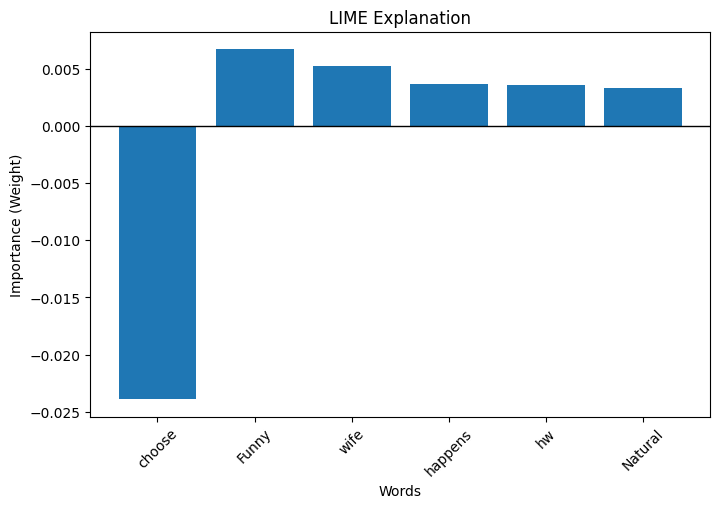

In [12]:
#using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(words, values)

plt.title("LIME Explanation")
plt.xlabel("Words")
plt.ylabel("Importance (Weight)")
plt.xticks(rotation=45)

plt.axhline(0, color='black', linewidth=1)
plt.show()

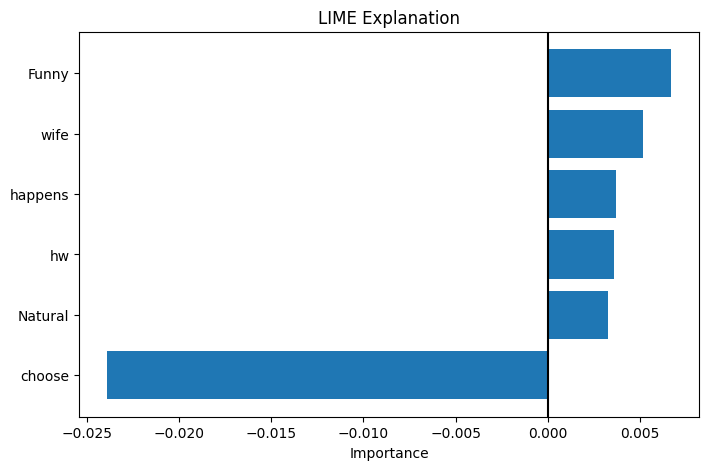

In [13]:
# Sort
import numpy as np

sorted_idx = np.argsort(values)

words = np.array(words)[sorted_idx]
values = np.array(values)[sorted_idx]

plt.figure(figsize=(8,5))
plt.barh(words, values)

plt.title("LIME Explanation")
plt.xlabel("Importance")
plt.axvline(0, color='black')
plt.show()

**SHAP**

We used SHAP LinearExplainer because the model is based on Logistic Regression with TF-IDF features.

In [14]:
#pip install shap

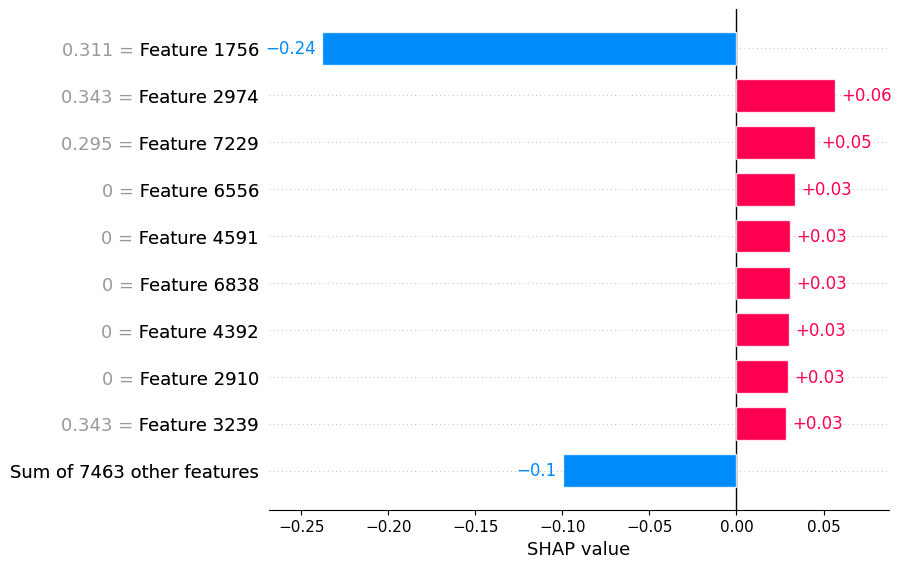

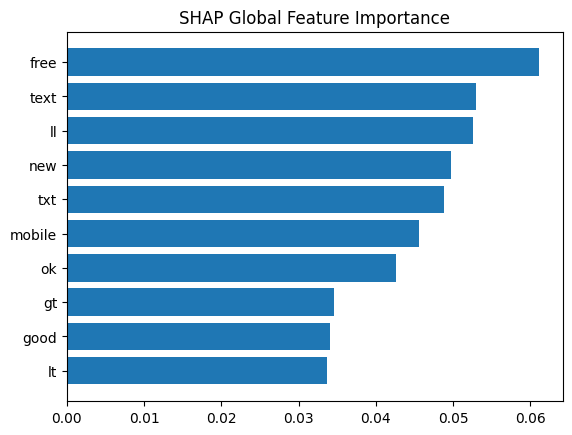

In [15]:

import shap
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.LinearExplainer(model, X_train_vec)
shap_values = explainer(X_test_vec)

shap.plots.bar(shap_values[0])

feature_names = vectorizer.get_feature_names_out()

mean_shap = np.abs(shap_values.values).mean(axis=0)

# top 10 features
top_idx = np.argsort(mean_shap)[-10:]

plt.barh(
    np.array(feature_names)[top_idx],
    mean_shap[top_idx]
)
plt.title("SHAP Global Feature Importance")
plt.show()

